# 02 — Preprocess CDFG JSON → PyG tensors


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ll_hls4ml.config import load_config
from ll_hls4ml.data.tensorize import create_graph_tensors
from ll_hls4ml.data.vocab import save_vocab, vocab_scan, load_vocab, make_local_types_global
from ll_hls4ml.viz.dataset import analyze_graph_dataset
from ll_hls4ml.viz.eda import plot_vocab_counts


In [3]:
cfg = load_config()

kernel_subset = ["2layer", "3layer", "conv1d", "conv2d", "exemplar"]
max_archives = 1

In [4]:
from ll_hls4ml.io.discovery import iter_graph_paths
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import tqdm

graph_dir = cfg.graph_dir
paths = list(iter_graph_paths(graph_dir, kernel_subset, max_archives))

# def process_graph(path):
#     graph_path = path[1]
#     ll_path = str(graph_path).replace("graphs", "ll").replace(".json", ".ll")
#     make_local_types_global(graph_path, ll_path)

# with ThreadPoolExecutor(max_workers=8) as executor:
#     list(tqdm.tqdm(
#         executor.map(process_graph, paths),
#         total=len(paths),
#         desc="Parsing graph files for building vocab",
#     ))

Parsing graph files for building vocab: 100%|██████████| 375/375 [00:47<00:00,  7.87it/s]


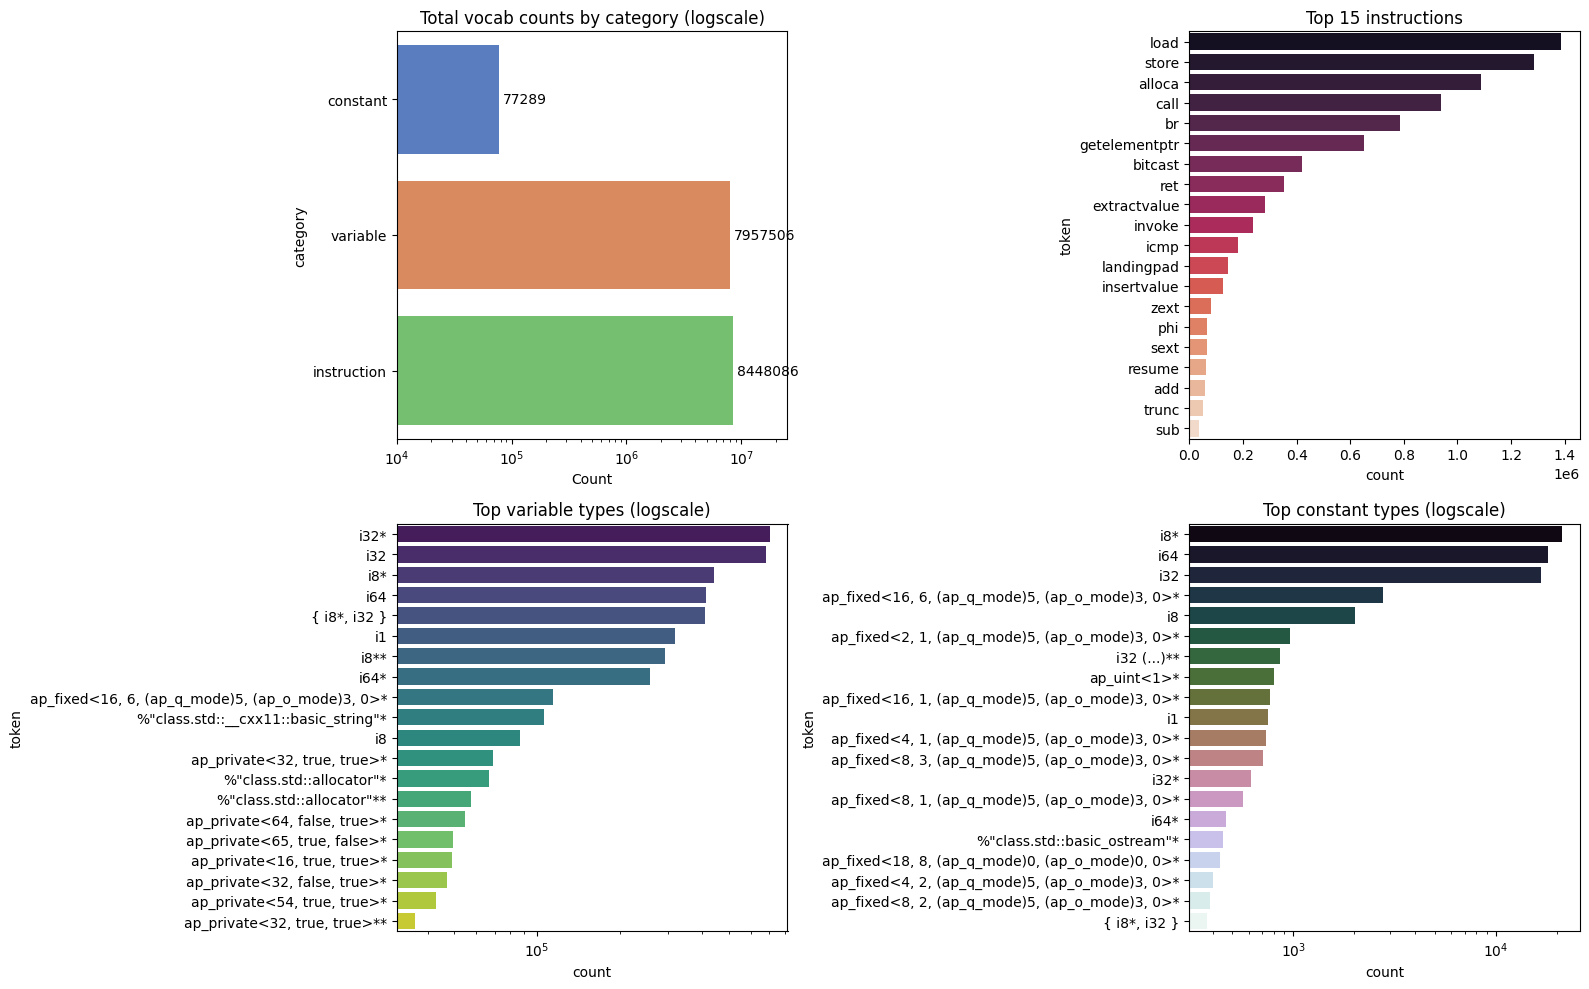

{'; undefined function': 1,
 'UNK': 0,
 '[external]': 2,
 'add': 3,
 'alloca': 4,
 'and': 5,
 'ashr': 6,
 'bitcast': 7,
 'br': 8,
 'call': 9,
 'extractvalue': 10,
 'fadd': 11,
 'fdiv': 12,
 'fmul': 13,
 'fneg': 14,
 'fpext': 15,
 'fptrunc': 16,
 'fsub': 17,
 'getelementptr': 18,
 'icmp': 19,
 'insertvalue': 20,
 'invoke': 21,
 'landingpad': 22,
 'load': 23,
 'lshr': 24,
 'mul': 25,
 'or': 26,
 'phi': 27,
 'ptrtoint': 28,
 'resume': 29,
 'ret': 30,
 'sdiv': 31,
 'select': 32,
 'sext': 33,
 'shl': 34,
 'sitofp': 35,
 'srem': 36,
 'store': 37,
 'sub': 38,
 'switch': 39,
 'trunc': 40,
 'udiv': 41,
 'unreachable': 42,
 'urem': 43,
 'xor': 44,
 'zext': 45}
8
{'constant': {'%"class.std::__cxx11::basic_string"*': 375,
              '%"class.std::basic_ostream"*': 450,
              '%class.ap_shift_reg*': 52,
              '%class.ap_shift_reg.149*': 2,
              '%class.ap_shift_reg.168*': 2,
              '%class.ap_shift_reg.172*': 2,
              '%class.ap_shift_reg.179*': 4,
       

In [5]:
instruction_vocab, max_pos, vocab_counts = vocab_scan(
    cfg.graph_dir, kernel_subset=kernel_subset, max_archives=max_archives
)
save_vocab(instruction_vocab, max_pos, "../artifacts/vocab/new_vocab.json", vocab_counts=vocab_counts)
instruction_vocab, max_pos, vocab_counts = load_vocab("../artifacts/vocab/new_vocab.json")
plot_vocab_counts(vocab_counts)
from pprint import pprint
pprint(instruction_vocab)
print(max_pos)
pprint(vocab_counts)


In [6]:
create_graph_tensors(cfg.graph_dir, cfg.tensor_dir, instruction_vocab, kernel_subset=kernel_subset, max_archives=max_archives, n_workers=8)

Processing graph files into PyTorch tensors: 100%|██████████| 375/375 [00:49<00:00,  7.64it/s]


Types not parsed by embedder:
   375  %"class.std::basic_istream"*
   375  %"class.std::__new_allocator"*
   375  %"class.std::__cxx11::basic_istringstream"*
   375  %"class.std::basic_ostream"*
   375  %struct._Guard*
   375  %struct._private_range_ref**
   375  %struct._private_range_ref*
   375  %"class.std::__cxx11::basic_istringstream"**
   375  %"class.std::basic_ifstream"*
   375  %"class.std::allocator"**
   375  %struct._private_bit_ref**
   375  %struct._IO_FILE*
   375  %struct._Guard**
   375  %"class.std::__new_allocator"**
   375  %"class.std::allocator"*
   375  %union.anon*
   375  %"struct.std::__cxx11::basic_string<char>::_Alloc_hider"*
   375  { i8*, i32 }
   375  %"class.std::basic_istream"**
   375  %struct._IO_FILE**
   375  %"class.std::__cxx11::basic_string"*
   375  %struct._private_bit_ref*
   375  %"class.std::__cxx11::basic_string"**
   375  %"class.std::basic_ios"*
   375  %"struct.std::__cxx11::basic_string<char>::_Alloc_hider"**
   100  %"class.nnet::Op_a